In [1]:
# Crear y explorar dataset financiero
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Crear dataset de transacciones financieras
np.random.seed(42)
n_transacciones = 2000

# Transacciones normales (distribución normal)
transacciones_normales = np.random.normal(150, 50, n_transacciones//2)

# Transacciones de lujo (distribución log-normal)
transacciones_lujo = np.random.lognormal(5.5, 0.8, n_transacciones//2)

# Combinar datasets
montos = np.concatenate([transacciones_normales, transacciones_lujo])

# Crear DataFrame
df = pd.DataFrame({
    'id_transaccion': range(1, len(montos) + 1),
    'monto': np.round(montos, 2),
    'tipo_cliente': np.random.choice(['Regular', 'Premium', 'VIP'], len(montos)),
    'categoria': np.random.choice(['Alimentos', 'Electrónicos', 'Ropa', 'Servicios'], len(montos))
})

print(f"Dataset creado: {len(df)} transacciones")
print(f"Rango de montos: ${df['monto'].min():.2f} - ${df['monto'].max():.2f}")
df

Dataset creado: 2000 transacciones
Rango de montos: $-12.06 - $3147.88


,id_transaccion,monto,tipo_cliente,categoria
0,1,174.84,Premium,Electrónicos
1,2,143.09,VIP,Alimentos
2,3,182.38,Premium,Alimentos
3,4,226.15,VIP,Servicios
4,5,138.29,VIP,Ropa
...,...,...,...,...
1995,1996,576.01,Regular,Electrónicos
1996,1997,239.55,Premium,Ropa
1997,1998,120.84,VIP,Alimentos
1998,1999,214.77,VIP,Ropa


In [3]:
# Análisis de distribuciones y medidas de forma
# Estadísticos descriptivos
print("ANÁLISIS DESCRIPTIVO")
print("=" * 25)
print(df['monto'].describe())

# Medidas de forma
print("\nMEDIDAS DE FORMA")
print("=" * 20)
skewness = df['monto'].skew()
kurtosis = df['monto'].kurtosis()

print(f"Asimetría (Skewness): {skewness:.3f}")
print(f"  Interpretación: {'Sesgo positivo (cola derecha)' if skewness > 0 else 'Sesgo negativo (cola izquierda)' if skewness < 0 else 'Simétrica'}")

print(f"Curtosis: {kurtosis:.3f}")
print(f"  Interpretación: {'Leptocúrtica (colas pesadas)' if kurtosis > 0 else 'Platicúrtica (colas ligeras)' if kurtosis < 0 else 'Mesocúrtica (normal)'}")

# Comparación media vs mediana
media = df['monto'].mean()
mediana = df['monto'].median()

print(f"\nMedia: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Diferencia: ${media - mediana:.2f} ({((media - mediana) / mediana * 100):.1f}%)")

ANÁLISIS DESCRIPTIVO
count    2000.000000
mean      252.769495
std       252.807549
min       -12.060000
25%       126.240000
50%       175.125000
75%       262.682500
max      3147.880000
Name: monto, dtype: float64

MEDIDAS DE FORMA
Asimetría (Skewness): 4.014
  Interpretación: Sesgo positivo (cola derecha)
Curtosis: 25.445
  Interpretación: Leptocúrtica (colas pesadas)

Media: $252.77
Mediana: $175.12
Diferencia: $77.64 (44.3%)


In [4]:
# Detección de outliers con múltiples métodos
# Método IQR
Q1 = df['monto'].quantile(0.25)
Q3 = df['monto'].quantile(0.75)
IQR = Q3 - Q1

limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

outliers_iqr = df[(df['monto'] < limite_inf_iqr) | (df['monto'] > limite_sup_iqr)]

# Método Z-Score
z_scores = stats.zscore(df['monto'])
outliers_zscore = df[abs(z_scores) > 3]

print("\nDETECCIÓN DE OUTLIERS")
print("=" * 25)
print(f"Método IQR: {len(outliers_iqr)} outliers")
print(f"  Límite inferior: ${limite_inf_iqr:.2f}")
print(f"  Límite superior: ${limite_sup_iqr:.2f}")

print(f"\nMétodo Z-Score (|z| > 3): {len(outliers_zscore)} outliers")

# Comparar métodos
outliers_comunes = set(outliers_iqr.index) & set(outliers_zscore.index)
print(f"Outliers detectados por ambos métodos: {len(outliers_comunes)}")


DETECCIÓN DE OUTLIERS
Método IQR: 229 outliers
  Límite inferior: $-78.42
  Límite superior: $467.35

Método Z-Score (|z| > 3): 41 outliers
Outliers detectados por ambos métodos: 41


C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


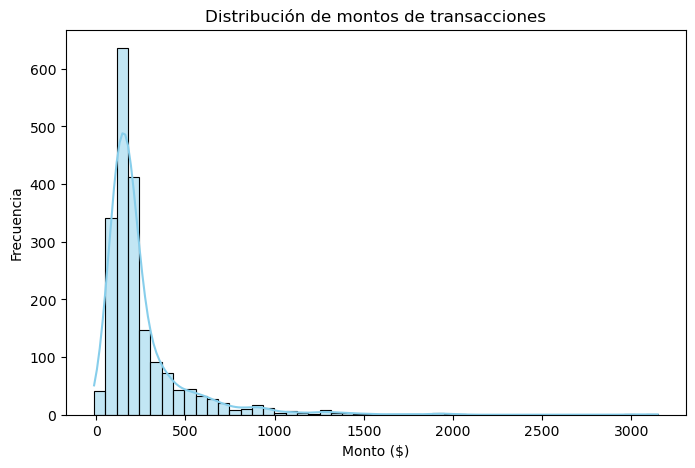

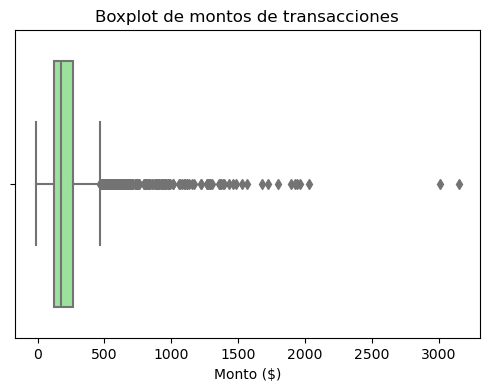

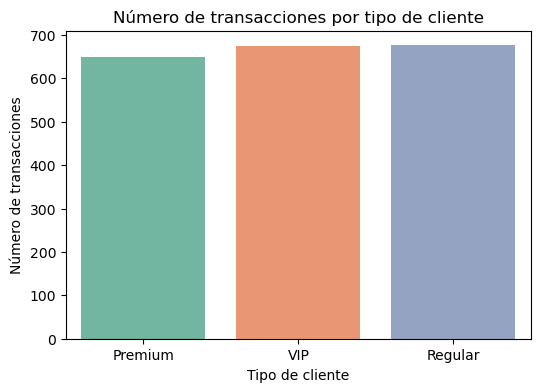

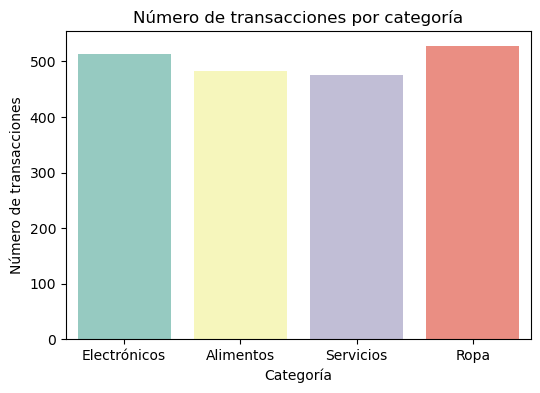

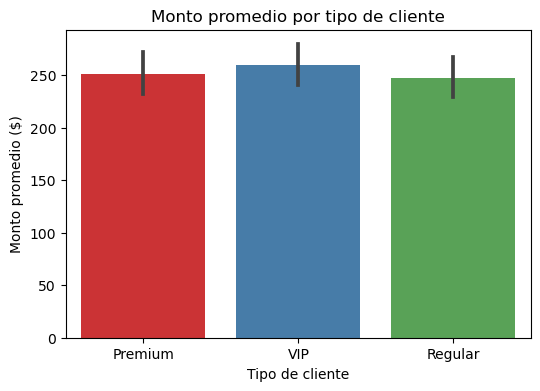

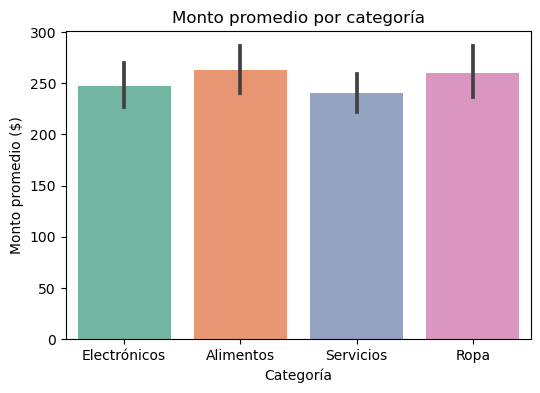

In [5]:
# ======================================
# Visualizaciones - Dataset financiero
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de montos ---
plt.figure(figsize=(8,5))
sns.histplot(df['monto'], bins=50, kde=True, color='skyblue')
plt.title("Distribución de montos de transacciones")
plt.xlabel("Monto ($)")
plt.ylabel("Frecuencia")
plt.show()

# 2. Boxplot de montos (para ver outliers) ---
plt.figure(figsize=(6,4))
sns.boxplot(x=df['monto'], color='lightgreen')
plt.title("Boxplot de montos de transacciones")
plt.xlabel("Monto ($)")
plt.show()

# 3. Transacciones por tipo de cliente ---
plt.figure(figsize=(6,4))
sns.countplot(x='tipo_cliente', data=df, palette='Set2')
plt.title("Número de transacciones por tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Número de transacciones")
plt.show()

# 4. Transacciones por categoría ---
plt.figure(figsize=(6,4))
sns.countplot(x='categoria', data=df, palette='Set3')
plt.title("Número de transacciones por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de transacciones")
plt.show()

# 5. Monto promedio por tipo de cliente ---
plt.figure(figsize=(6,4))
sns.barplot(x='tipo_cliente', y='monto', data=df, estimator=np.mean, palette='Set1')
plt.title("Monto promedio por tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Monto promedio ($)")
plt.show()

# 6. Monto promedio por categoría ---
plt.figure(figsize=(6,4))
sns.barplot(x='categoria', y='monto', data=df, estimator=np.mean, palette='Set2')
plt.title("Monto promedio por categoría")
plt.xlabel("Categoría")
plt.ylabel("Monto promedio ($)")
plt.show()

In [7]:
import pandas as pd
import numpy as np
from scipy import stats

# Agrupación con funciones explícitas
categoria_stats = df.groupby('categoria').agg({
    'monto': [
        'count',
        'mean',
        'median',
        'std',
        lambda x: x.skew(),          # asimetría
        lambda x: x.kurt()           # curtosis
    ]
}).round(3)

# Renombrar columnas para mayor claridad
categoria_stats.columns = ['count', 'mean', 'median', 'std', 'skew', 'kurtosis']

print(categoria_stats)
# Análisis por categorías
print("\nANÁLISIS POR CATEGORÍA")
print("=" * 25)

categoria_stats = df.groupby('categoria').agg({
    'monto': ['count', 'mean', 'median', 'std', 'skew', 'kurtosis']
}).round(3)

print(categoria_stats)

# Análisis por tipo de cliente
print("\nANÁLISIS POR TIPO DE CLIENTE")
print("=" * 30)

cliente_stats = df.groupby('tipo_cliente').agg({
    'monto': ['count', 'mean', 'median', 'skew']
}).round(2)

print(cliente_stats)

              count     mean   median      std   skew  kurtosis
categoria                                                      
Alimentos       482  262.608  182.595  243.438  2.907    10.689
Electrónicos    514  247.375  173.040  250.737  4.687    35.573
Ropa            528  260.260  174.835  292.607  4.359    27.036
Servicios       476  240.323  172.460  213.819  2.987    12.837

ANÁLISIS POR CATEGORÍA


AttributeError: 'SeriesGroupBy' object has no attribute 'kurtosis'

In [9]:
import pandas as pd
import numpy as np

# --- Análisis por categorías ---
print("\nANÁLISIS POR CATEGORÍA")
print("=" * 25)

categoria_stats = df.groupby('categoria')['monto'].agg(
    conteo='count',
    media='mean',
    mediana='median',
    desv_std='std',
    asimetria=lambda x: x.skew(),
    curtosis=lambda x: x.kurtosis()
).round(3)

print(categoria_stats)

# --- Análisis por tipo de cliente ---
print("\nANÁLISIS POR TIPO DE CLIENTE")
print("=" * 30)

cliente_stats = df.groupby('tipo_cliente')['monto'].agg(
    conteo='count',
    media='mean',
    mediana='median',
    asimetria=lambda x: x.skew()
).round(2)

print(cliente_stats)


ANÁLISIS POR CATEGORÍA
              conteo    media  mediana  desv_std  asimetria  curtosis
categoria                                                            
Alimentos        482  262.608  182.595   243.438      2.907    10.689
Electrónicos     514  247.375  173.040   250.737      4.687    35.573
Ropa             528  260.260  174.835   292.607      4.359    27.036
Servicios        476  240.323  172.460   213.819      2.987    12.837

ANÁLISIS POR TIPO DE CLIENTE
              conteo   media  mediana  asimetria
tipo_cliente                                    
Premium          650  251.22   173.57       3.39
Regular          676  247.64   175.92       4.68
VIP              674  259.41   177.86       4.06



Gráfico guardado como 'distribucion_montos.png'


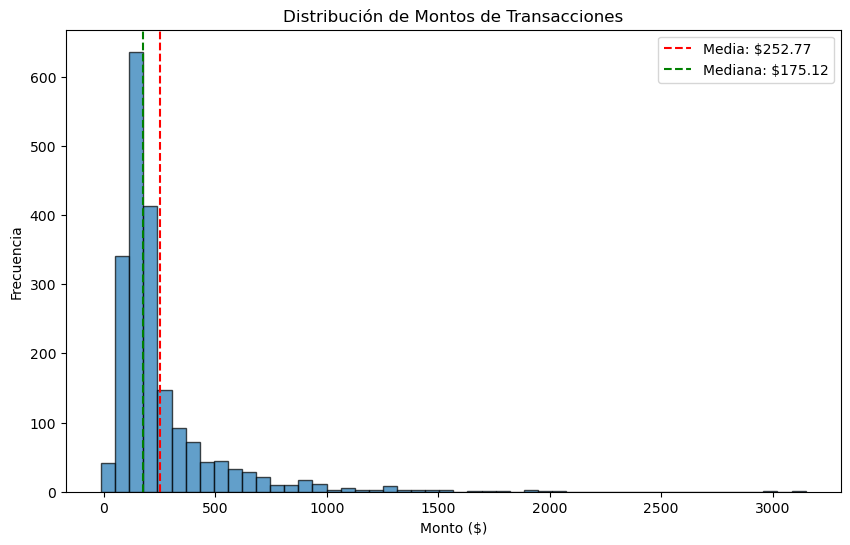

In [10]:
# Visualización básica de distribuciones
import matplotlib.pyplot as plt

# Histograma simple (si matplotlib está disponible)
try:
    plt.figure(figsize=(10, 6))
    plt.hist(df['monto'], bins=50, alpha=0.7, edgecolor='black')
    plt.axvline(df['monto'].mean(), color='red', linestyle='--', label=f'Media: ${df["monto"].mean():.2f}')
    plt.axvline(df['monto'].median(), color='green', linestyle='--', label=f'Mediana: ${df["monto"].median():.2f}')
    plt.title('Distribución de Montos de Transacciones')
    plt.xlabel('Monto ($)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.savefig('distribucion_montos.png', dpi=100, bbox_inches='tight')
    print("\nGráfico guardado como 'distribucion_montos.png'")
except ImportError:
    print("\nMatplotlib no disponible - omitiendo visualización")

In [ ]:
# La asimetría desplaza la media hacia la cola más larga, mientras que la mediana refleja mejor el valor típico en 
# distribuciones sesgadas. 
# La curtosis indica la “pesadez” de las colas, mostrando mayor probabilidad de valores extremos. 
# Esto afecta la interpretación de medidas centrales, pues la media puede distorsionarse frente a outliers.
# En finanzas, algunos outliers son válidos: transacciones altas de clientes premium reflejan comportamientos reales de gasto.